In [8]:
import matplotlib.pyplot as plt
plt.rc('font', family='Malgun Gothic')

In [9]:
waiting_result =  [70.98404576490948, 69.36048920759383, 72.76358607600802, 68.70991068599038, 69.31562237235062, 69.69579049613057, 70.94853800321773, 70.05164677474126, 68.07729937284829, 69.86933082655908]
waiting_result1 =  [67.58491113108536, 66.63014408865683, 68.85319092332018, 67.77328774544452, 65.98981610205762, 67.2991721743979, 66.22424935384946, 68.29182658289736, 70.25622255354212, 72.24511934392504]
left_right_result =  [33.31346836748868, 31.928098610642632, 31.015136786557427, 30.87031563076563, 31.80593303840082, 31.054952685143025, 32.165142407469816, 32.01045489713738, 31.971313508044563, 31.568413117225692]
left_right_result1 =  [26.51451848618912, 26.181886113701147, 27.937475615159226, 25.875830737794473, 26.933455009555512, 26.06685579383822, 26.63323215690933, 26.56309639534191, 26.631030081800773, 27.28191851660823]
right_left_result =  [98.46296479986212, 100.62674496267057, 97.96829144100347, 97.16336355400327, 99.2082647251374, 98.86050217893013, 98.35201460114682, 101.84930003108065, 97.75989445910335, 99.57355790531656]
right_left_result1 =  [90.71181912565078, 88.52874931391814, 87.51338107802468, 88.23677267046259, 87.6445268844937, 88.63365537855199, 87.73811177019063, 91.73597582346333, 88.22398344145292, 85.17383828965556]
up_down_result =  [89.33614483368542, 82.76645787500267, 98.28592520044758, 84.25223104978114, 84.26066555083683, 87.47382308012754, 91.52595765208044, 84.05383024287538, 80.14462172651464, 85.10241998552834]
up_down_result1 =  [86.72880959515899, 85.59509278682056, 92.49692659645223, 91.20541737624126, 82.93101104378799, 88.31696621083336, 82.90587564592637, 89.55050833583051, 98.42355228440523, 111.15684225144146]
down_up_result =  [63.48641855297893, 62.636800444382786, 64.64751423413432, 63.096194972920436, 62.54445215942229, 62.04588251631704, 62.49541035967214, 62.83702263574517, 62.87614914595191, 63.77966949034865]
down_up_result1 =  [66.8931051242882, 66.69935425635335, 68.09077905846429, 66.41088737675324, 66.8622899597278, 66.73265518677961, 68.00193028746008, 65.92354534092456, 68.51325510345792, 66.51260241633102]

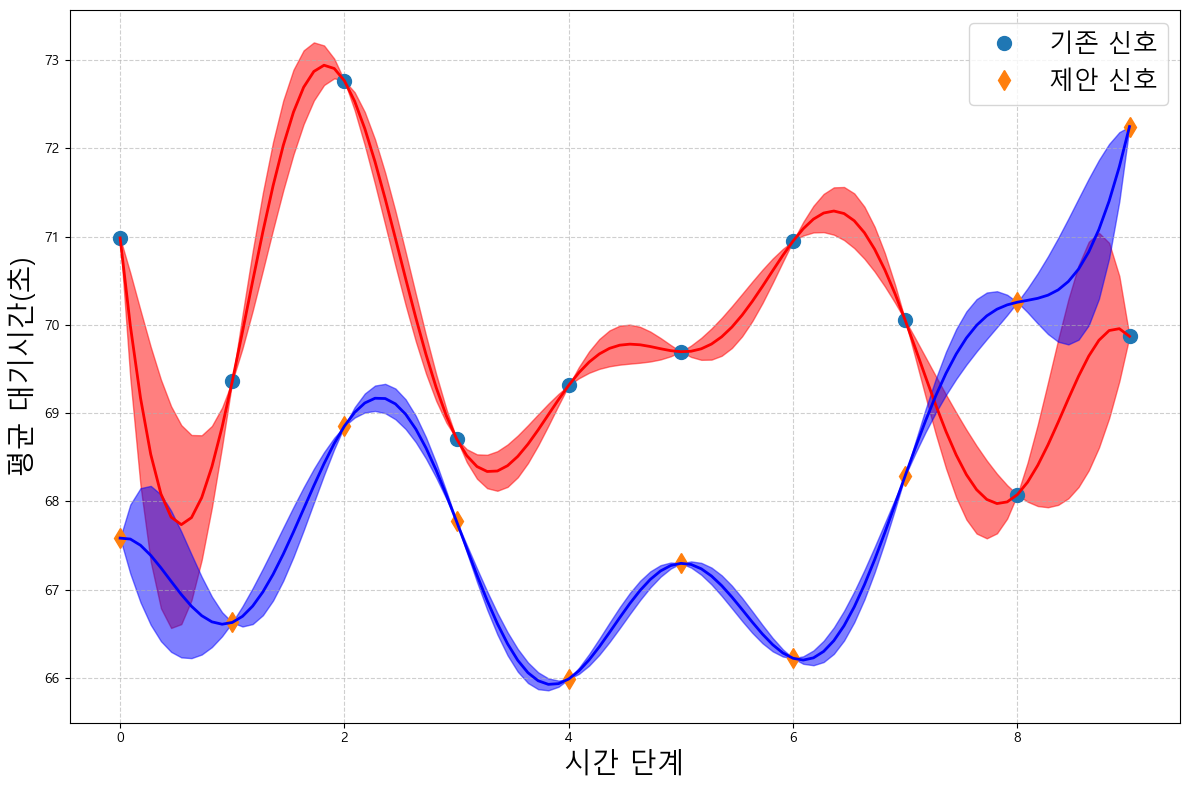

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

# 데이터 포인트
x = np.arange(len(waiting_result))
y1 = waiting_result
y2 = waiting_result1

# 가우시안 프로세스 모델 생성
kernel = 1.0 * RBF(length_scale=1.0)
gp1 = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)
gp2 = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)
gp1.fit(x.reshape(-1, 1), y1)
gp2.fit(x.reshape(-1, 1), y2)

# 새로운 x 값 생성
x_new = np.linspace(0, len(waiting_result) - 1, 100).reshape(-1, 1)

# 평균 및 표준편차 예측
y_mean1, y_std1 = gp1.predict(x_new, return_std=True)
y_mean2, y_std2 = gp2.predict(x_new, return_std=True)

# 그래프 그리기
plt.figure(figsize=(12, 8))

# 그림자 표시
plt.fill_between(x_new.flatten(), y_mean1 - 1.96 * y_std1, y_mean1 + 1.96 * y_std1, alpha=0.5, color='red')
plt.fill_between(x_new.flatten(), y_mean2 - 1.96 * y_std2, y_mean2 + 1.96 * y_std2, alpha=0.5, color='blue')

# 데이터 그래프
plt.plot(x, y1, 'o', label='기존 신호', markersize=10)
plt.plot(x, y2, 'd', label='제안 신호', markersize=10)

plt.plot(x_new, y_mean1, 'r-', linewidth=2)
plt.plot(x_new, y_mean2, 'b-', linewidth=2)

plt.xlabel('시간 단계', fontsize=20)
plt.ylabel('평균 대기시간(초)', fontsize=20)
plt.legend(fontsize=18)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


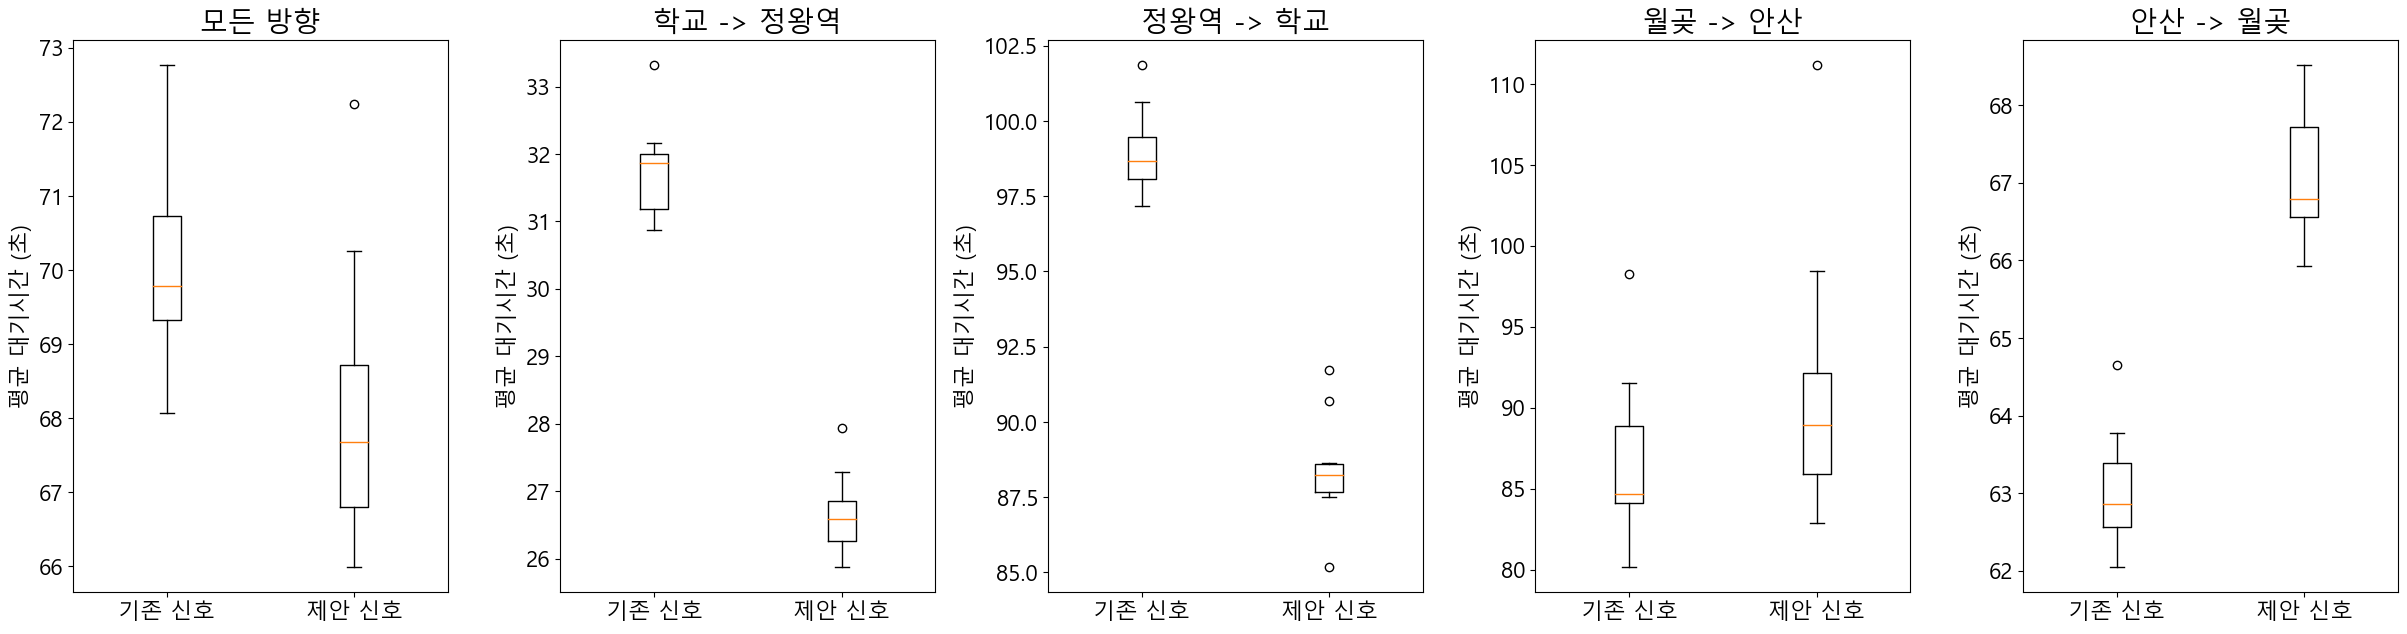

In [11]:
# Group data by categories
waiting_data = [waiting_result, waiting_result1]
left_right_data = [left_right_result, left_right_result1]
right_left_data = [right_left_result, right_left_result1]
up_down_data = [up_down_result, up_down_result1]
down_up_data = [down_up_result, down_up_result1]

data_categories = [waiting_data, left_right_data, right_left_data, up_down_data, down_up_data]
category_names = ['모든 방향', '학교 -> 정왕역', '정왕역 -> 학교', '월곶 -> 안산', '안산 -> 월곶']

# Create subplots with adjusted spacing and increased figure size
fig, axes = plt.subplots(1, 5, figsize=(30, 8), sharey=False, gridspec_kw={'wspace': 0.3})

# Define box style with wider boxes
boxprops = dict(linewidth=2, color='blue')

# Plot each category in a separate subplot
for i, ax in enumerate(axes):
    boxplot = ax.boxplot(data_categories[i])
    for box in boxplot['boxes']:
        box.set(linewidth=1)  # Set the box color and width
    ax.set_title(category_names[i], fontsize=20)
    ax.set_xticklabels(['기존 신호', '제안 신호'], fontsize=16)
    ax.set_ylabel('평균 대기시간 (초)', fontsize=16)
    ax.tick_params(axis='both', labelsize=16)

    # Set individual y-axis limits for each subplot
    # if i == 0:
    #     ax.set_ylim(45, 80)  # Adjust the y-axis limits for the first subplot
    # elif i == 1:
    #     ax.set_ylim(150, 400)  # Adjust the y-axis limits for the second subplot

# Adjust the layout
plt.subplots_adjust(top=0.8)

# Show the plot
plt.show()


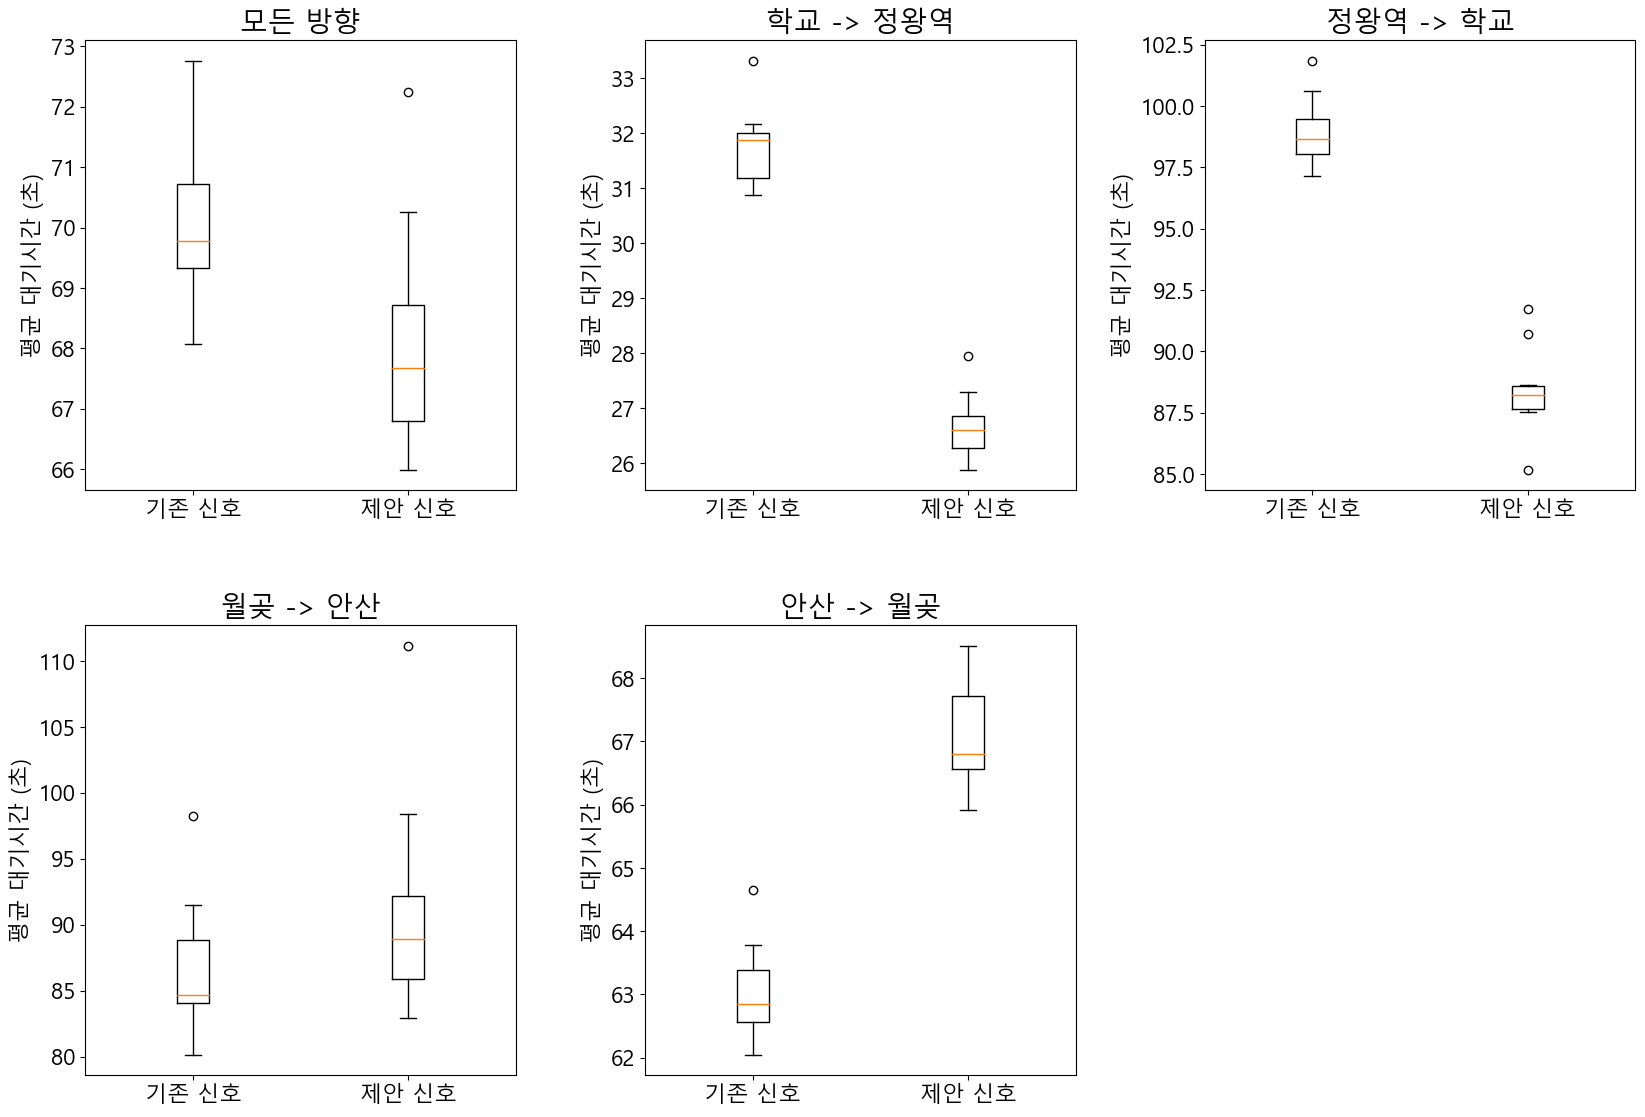

In [12]:
# Group data by categories
waiting_data = [waiting_result, waiting_result1]
left_right_data = [left_right_result, left_right_result1]
right_left_data = [right_left_result, right_left_result1]
up_down_data = [up_down_result, up_down_result1]
down_up_data = [down_up_result, down_up_result1]

data_categories = [waiting_data, left_right_data, right_left_data, up_down_data, down_up_data]
category_names = ['모든 방향', '학교 -> 정왕역', '정왕역 -> 학교', '월곶 -> 안산', '안산 -> 월곶']

# Create subplots with 3 rows and 2 columns
fig, axes = plt.subplots(2, 3, figsize=(20, 15), sharey=False, gridspec_kw={'wspace': 0.3, 'hspace': 0.3})

# Plot each category in separate subplots
for i, ax in enumerate(axes.flat[:-1]):  # Exclude the last subplot
    if i < len(data_categories):
        boxplot = ax.boxplot(data_categories[i])
        for box in boxplot['boxes']:
            box.set(linewidth=1)  # Set the box color and width
        ax.set_title(category_names[i], fontsize=20)
        ax.set_xticklabels(['기존 신호', '제안 신호'], fontsize=16)
        ax.set_ylabel('평균 대기시간 (초)', fontsize=16)
        ax.tick_params(axis='both', labelsize=16)

        # Set individual y-axis limits for each subplot
        # if i == 0:
        #     ax.set_ylim(45, 80)  # Adjust the y-axis limits for the first subplot
        # elif i == 1:
        #     ax.set_ylim(150, 400)  # Adjust the y-axis limits for the second subplot

# Remove the last subplot (3rd row, 2nd column)
fig.delaxes(axes[1, 2])

# Adjust the layout
plt.subplots_adjust(top=0.8)

# Show the plot
plt.show()
